# Marketing Campaign ROI Analyzer
## Exploratory Data Analysis & Data Cleaning

### Section 1 — Import Libraries
### Section 2 — Load Data
### Section 3 — Missing Value Analysis
### Section 4 — Data Cleaning
### Section 5 — Feature Engineering
### Section 6 — Visualizations

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Path to dataset files: /kaggle/input/customer-personality-analysis


In [48]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print(os.listdir(path))


['marketing_campaign.csv']


In [4]:
file_path = os.path.join(path, "marketing_campaign.csv")

df = pd.read_csv(file_path, sep="\t")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Customer Personality Analysis - Data Dictionary

## People
- **ID**: Customer's unique identifier  
- **Year_Birth**: Customer's birth year  
- **Education**: Customer's education level  
- **Marital_Status**: Customer's marital status  
- **Income**: Customer's yearly household income  
- **Kidhome**: Number of children in customer's household  
- **Teenhome**: Number of teenagers in customer's household  
- **Dt_Customer**: Date of customer's enrollment with the company  
- **Recency**: Number of days since customer's last purchase  
- **Complain**: 1 if the customer complained in the last 2 years, 0 otherwise  

## Products
- **MntWines**: Amount spent on wine in last 2 years  
- **MntFruits**: Amount spent on fruits in last 2 years  
- **MntMeatProducts**: Amount spent on meat in last 2 years  
- **MntFishProducts**: Amount spent on fish in last 2 years  
- **MntSweetProducts**: Amount spent on sweets in last 2 years  
- **MntGoldProds**: Amount spent on gold in last 2 years  

## Promotion
- **NumDealsPurchases**: Number of purchases made with a discount  
- **AcceptedCmp1**: 1 if customer accepted the offer in the 1st campaign  
- **AcceptedCmp2**: 1 if customer accepted the offer in the 2nd campaign  
- **AcceptedCmp3**: 1 if customer accepted the offer in the 3rd campaign  
- **AcceptedCmp4**: 1 if customer accepted the offer in the 4th campaign  
- **AcceptedCmp5**: 1 if customer accepted the offer in the 5th campaign  
- **Response**: 1 if customer accepted the offer in the last campaign  

## Place
- **NumWebPurchases**: Purchases made through the website  
- **NumCatalogPurchases**: Purchases made using catalogue  
- **NumStorePurchases**: Purchases made in physical stores  
- **NumWebVisitsMonth**: Website visits in the last month  

In [33]:
print("shape:", df.shape)
df.info()


shape: (2236, 30)
<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2236 non-null   int64  
 1   Year_Birth           2236 non-null   int64  
 2   Education            2236 non-null   object 
 3   Marital_Status       2236 non-null   object 
 4   Income               2236 non-null   float64
 5   Kidhome              2236 non-null   int64  
 6   Teenhome             2236 non-null   int64  
 7   Dt_Customer          2236 non-null   object 
 8   Recency              2236 non-null   int64  
 9   MntWines             2236 non-null   int64  
 10  MntFruits            2236 non-null   int64  
 11  MntMeatProducts      2236 non-null   int64  
 12  MntFishProducts      2236 non-null   int64  
 13  MntSweetProducts     2236 non-null   int64  
 14  MntGoldProds         2236 non-null   int64  
 15  NumDealsPurchases    2236

In [12]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print(missing_df[missing_df['Missing Count'] > 0])

        Missing Count  Missing %
Income             24   1.071429


In [13]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [18]:
df['Income'].fillna(df['Income'].median())
df['Income'].isnull().sum()


np.int64(0)

In [19]:
# Anyone born before 1940 is unrealistic for this dataset
print("Before:", df.shape)
df = df[df['Year_Birth'] >= 1940]
print("After:", df.shape)

Before: (2240, 29)
After: (2237, 29)


In [20]:
# Flag and remove the extreme income outlier
print("Before:", df.shape)
df = df[df['Income'] < 200000]
print("After:", df.shape)

Before: (2237, 29)
After: (2236, 29)


In [22]:
df['Marital_Status'] = df['Marital_Status'].replace(['Absurd','YOLO','Alone'],'Other')
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,578
Single,479
Divorced,231
Widow,77
Other,7


In [28]:
import datetime
current_date = datetime.datetime.now().year
df['Age'] = current_date - df['Year_Birth']
df['Age'].describe()

,Age
count,2236.000000
mean,57.101968
std,11.703281
min,30.000000
25%,49.000000
50%,56.000000
75%,67.000000
max,86.000000


In [41]:
# How many days have they been a customer?
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Tenure'] = (pd.Timestamp.now() - df['Dt_Customer']).dt.days
df['Customer_Tenure'].describe()

,Customer_Tenure
count,2236.000000
mean,4688.773256
std,202.181561
min,4335.000000
25%,4515.750000
50%,4691.000000
75%,4864.000000
max,5034.000000


In [45]:
df['Total_Spend'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'])

df['Total_Spend'].describe()

,Total_Spend
count,2236.000000
mean,605.986583
std,601.865156
min,5.000000
25%,69.000000
50%,396.500000
75%,1045.500000
max,2525.000000


In [44]:
df['Total_Campaigns_Accepted'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] +
                                   df['AcceptedCmp3'] + df['AcceptedCmp4'] +
                                   df['AcceptedCmp5'])

df['Total_Campaigns_Accepted'].value_counts().sort_index()

,count
Total_Campaigns_Accepted,
0,1774
1,324
2,83
3,44
4,11


In [47]:
new_columns = ['Age', 'Customer_Tenure', 'Total_Spend', 'Total_Campaigns_Accepted']
df[new_columns].head()

,Age,Customer_Tenure,Total_Spend,Total_Campaigns_Accepted
0,69,4998,1617,0
1,72,4448,27,0
2,61,4647,776,0
3,42,4474,53,0
4,45,4496,422,0


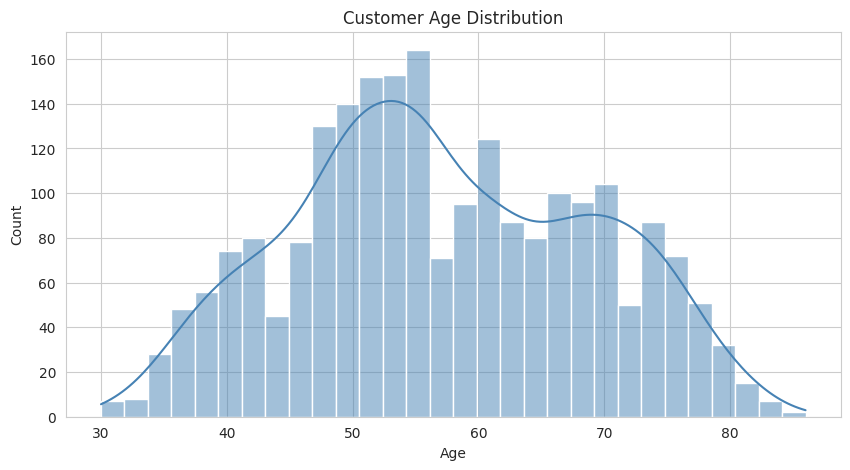

In [52]:
sns.histplot(df['Age'], bins=30, color='steelblue', kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

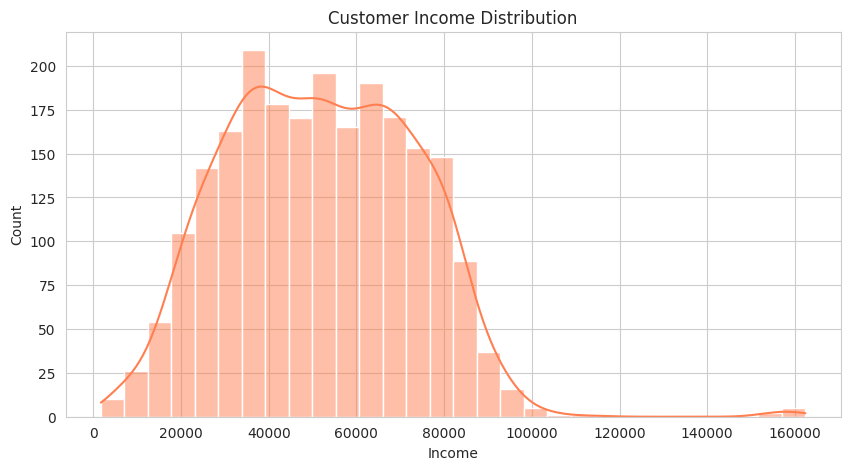

In [53]:
sns.histplot(df['Income'], bins=30, color='coral', kde=True)
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

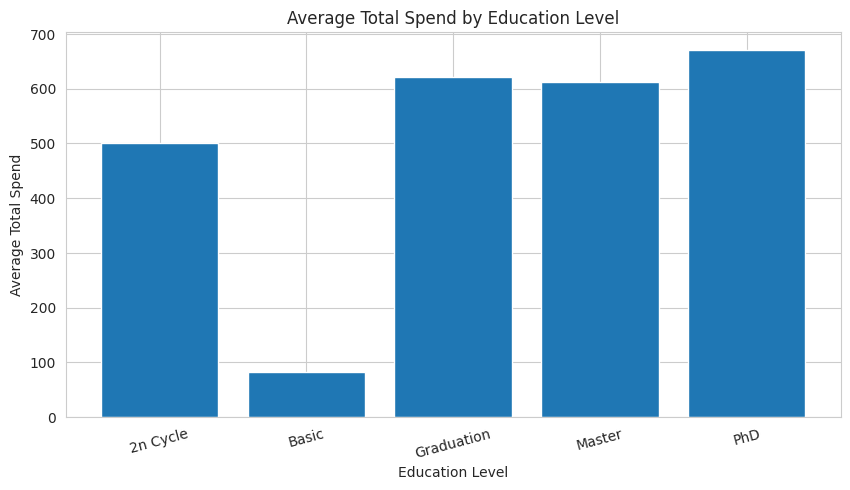

In [61]:
avg_spend = df.groupby('Education')['Total_Spend'].mean().reset_index()
plt.bar(avg_spend['Education'], avg_spend['Total_Spend'])
plt.title('Average Total Spend by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Spend')
plt.xticks(rotation=15)
plt.show()

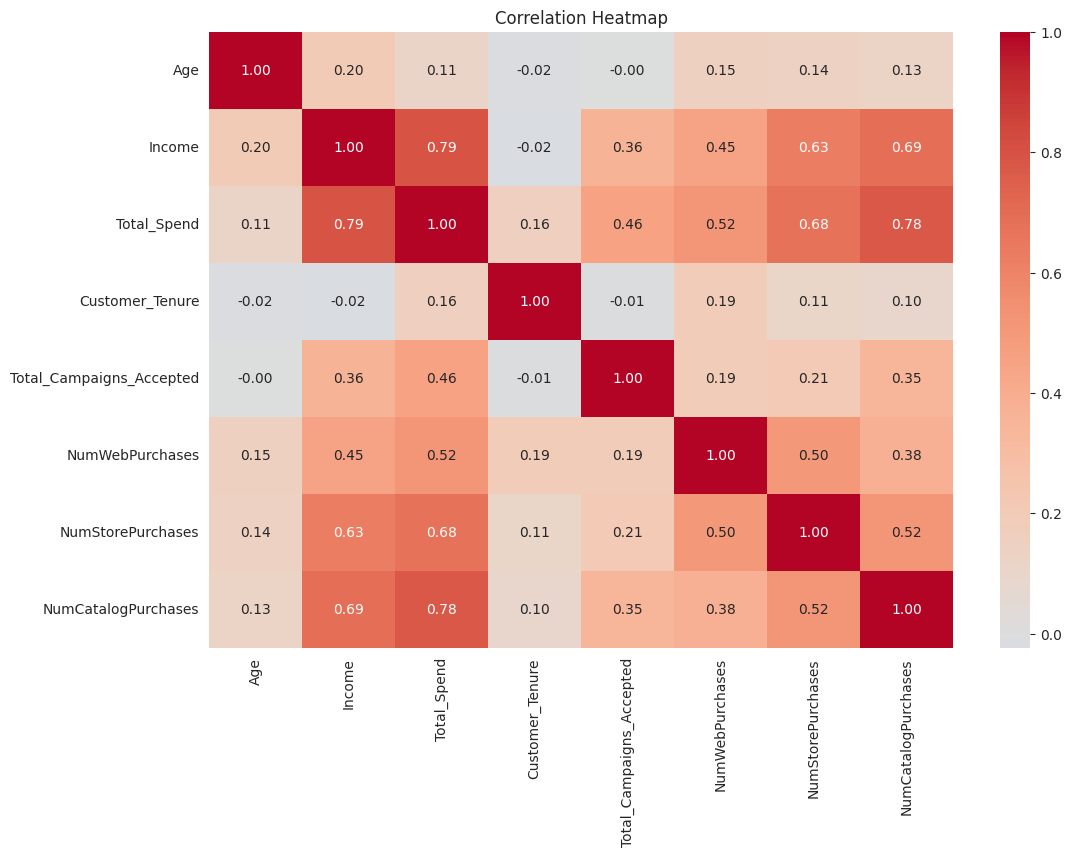

In [62]:
plt.figure(figsize=(12,8))
numeric_cols = ['Age', 'Income', 'Total_Spend', 'Customer_Tenure',
                'Total_Campaigns_Accepted', 'NumWebPurchases',
                'NumStorePurchases', 'NumCatalogPurchases']

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.show()

In [63]:
df.to_csv('cleaned_data.csv', index=False)
print("Saved! Shape:", df.shape)

Saved! Shape: (2236, 33)


In [64]:
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>